<a href="https://colab.research.google.com/github/Horeisan/PlantType-Image-Classifier/blob/main/PlantType.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries

In [ ]:
!pip -q install kagglehub torch torchvision pytorch-lightning torchmetrics scikit-learn matplotlib
import os, math, itertools
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor

from torchmetrics.classification import (
    MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score, MulticlassConfusionMatrix
)

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

pl.seed_everything(42, workers=True)
device = "cuda" if torch.cuda.is_available() else "cpu"



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 48.5 MB/s eta 0:00:00


INFO:lightning_fabric.utilities.seed:Seed set to 42


In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA GPU")

True
Tesla T4


In [ ]:
import kagglehub, os
base_path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")
print("Base path:", base_path)
print(os.listdir(base_path))

DATA_ROOT = Path(base_path) / "split_ttv_dataset_type_of_plants"
TRAIN_DIR = DATA_ROOT / "Train_Set_Folder"
VAL_DIR   = DATA_ROOT / "Validation_Set_Folder"
TEST_DIR  = DATA_ROOT / "Test_Set_Folder"

print("Train:", TRAIN_DIR.exists(), "Val:", VAL_DIR.exists(), "Test:", TEST_DIR.exists())


100%|██████████| 937M/937M [00:09<00:00, 109MB/s] 

Extracting files...


Base path: /root/.cache/kagglehub/datasets/yudhaislamisulistya/plants-type-datasets/versions/16
['split_ttv_dataset_type_of_plants']
Train: True Val: True Test: True


# Loading and preprocess and applying transforms


Applying data preprocessing, including `normalization and conversion of images to tensors` for use in TensorFlow.


In [ ]:
# Define transformations for the data
IMG_SIZE = 192
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)


#Train/Test/Validation Split
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


train_ds = datasets.ImageFolder(TRAIN_DIR.as_posix(), transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR.as_posix(),   transform=eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR.as_posix(),  transform=eval_tf)

num_classes = len(train_ds.classes)
class_names = train_ds.classes
print(f"Classes ({num_classes}):", class_names[:10], "..." if num_classes>10 else "")
print("Num images — Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

BATCH_SIZE = 128
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
len(train_loader), len(val_loader), len(test_loader)

Classes (30): ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant'] ...
Num images — Train: 23972 Val: 3030 Test: 2998


(188, 24, 24)

The plant dataset is organized into three separate folders for training, validation. All images are converted to tensors and normalized.The batch size is 32 for each split with the ratio of `80/10/10`








#Displaying some samples

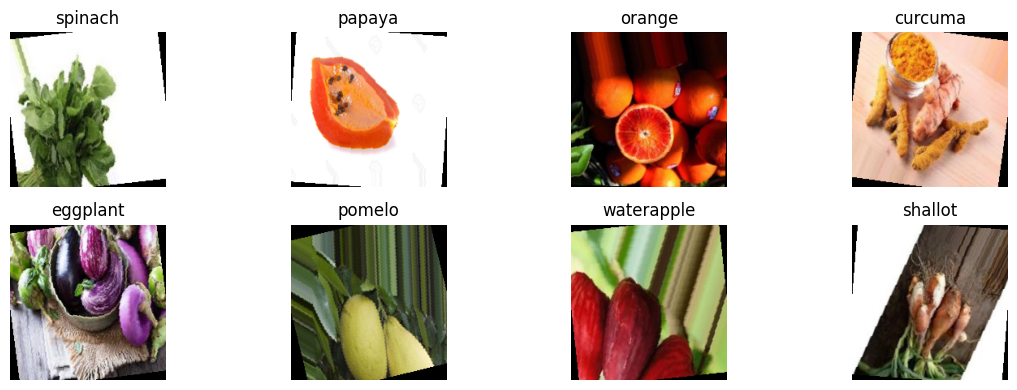

In [ ]:
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(MEAN, STD)],
    std=[1/s for s in STD]
)

def show_batch(loader, n=8):
    xb, yb = next(iter(loader))
    imgs = torch.clamp(inv_norm(xb.clone()), 0, 1)
    n = min(n, xb.size(0))
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(2, math.ceil(n/2), i+1)
        plt.imshow(np.transpose(imgs[i].numpy(), (1,2,0)))
        plt.title(class_names[yb[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, n=8)

#Defining a simple CNN Model

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int, input_size: int = IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, input_size, input_size)
            flattened_size = self.features(dummy_input).view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

This `SimpleCNN` class defines a compact convolutional neural network for multiclass image classification. It uses `two`convolutional layers with ReLU activations and max pooling, followed by a global average pooling layer and a fully connected layer to produce class scores. The module takes num_classes as a parameter to determine the number of output categories.

#Defining SimpleLightningModule

In [ ]:
class SimpleLightningModule(pl.LightningModule):
    def __init__(self, model: nn.Module, num_classes: int, lr=0.001, weight_decay=0.0001):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay

        self.acc  = MulticlassAccuracy(num_classes=num_classes)
        self.prec = MulticlassPrecision(num_classes=num_classes, average="macro")
        self.rec  = MulticlassRecall(num_classes=num_classes, average="macro")
        self.f1   = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, x): return self.model(x)

    def _shared_step(self, batch, stage: str):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)
        self.acc.update(preds, y)
        self.prec.update(preds, y)
        self.rec.update(preds, y)
        self.f1.update(preds, y)
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, batch_size=x.size(0))
        return loss

    def training_step(self, batch, idx): return self._shared_step(batch, "train")
    def validation_step(self, batch, idx): return self._shared_step(batch, "val")
    def test_step(self, batch, idx): return self._shared_step(batch, "test")

    def _epoch_metrics(self, stage: str):
        self.log(f"{stage}_acc",  self.acc.compute(),  prog_bar=True)
        self.log(f"{stage}_precision", self.prec.compute(), prog_bar=False)
        self.log(f"{stage}_recall",    self.rec.compute(),  prog_bar=False)
        self.log(f"{stage}_f1",        self.f1.compute(),   prog_bar=True)
        self.acc.reset(); self.prec.reset(); self.rec.reset(); self.f1.reset()

    def on_train_epoch_end(self): self._epoch_metrics("train")
    def on_validation_epoch_end(self): self._epoch_metrics("val")
    def on_test_epoch_end(self): self._epoch_metrics("test")

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", patience=2, factor=0.5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}


This `SimpleImageLightningModule` is a PyTorch Lightning module designed for multiclass image classification using a CNN. It takes `num_classes` to define the number of output categories and learning_rate to configure the Adam optimizer. The module tracks training, validation, and test accuracy separately using torchmetrics.Accuracy and logs both loss and accuracy for monitoring during training.

In [ ]:
baseline = SimpleLightningModule(SimpleCNN(num_classes).to(device), num_classes=num_classes, lr=0.001, weight_decay=0.0001)

ckpt_cb = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="simplecnn-best")
es_cb   = EarlyStopping(monitor="val_loss", mode="min", patience=5)
lr_cb   = LearningRateMonitor(logging_interval='epoch')

trainer_baseline = pl.Trainer(
    max_epochs=15,
    accelerator="auto", devices=1,
    callbacks=[ckpt_cb, es_cb, lr_cb],
    log_every_n_steps=10, deterministic=True
)

trainer_baseline.fit(baseline, train_dataloaders=train_loader, val_dataloaders=val_loader)
best_simplecnn_path = ckpt_cb.best_model_path
best_simplecnn_path

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ SimpleCNN           │ 19.0 M │ train │     0 │
│ 1 │ acc   │ MulticlassAccuracy  │      0 │ train │     0 │
│ 2 │ prec  │ MulticlassPrecision │      0 │ train │     0 │
│ 3 │ rec   │ MulticlassRecall    │      0 │ train │     0 │
│ 4 │ f1    │ MulticlassF1Score   │      0 │ train │     0 │
└───┴───────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 19.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.0 M                                                                                               
Total estimated model params size (MB): 75                                                                         
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassPrecision was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassRecall was called before the ``update`` method which may lead to errors, as metric states have not
yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassF1Score was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


'/content/lightning_logs/version_0/checkpoints/simplecnn-best.ckpt'

#Creating the confusion matrix

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7348013520240784     │
│          test_f1          │    0.7326453924179077     │
│         test_loss         │    0.8098556399345398     │
│      test_precision       │    0.7442073822021484     │
│        test_recall        │    0.7348013520240784     │
└───────────────────────────┴───────────────────────────┘

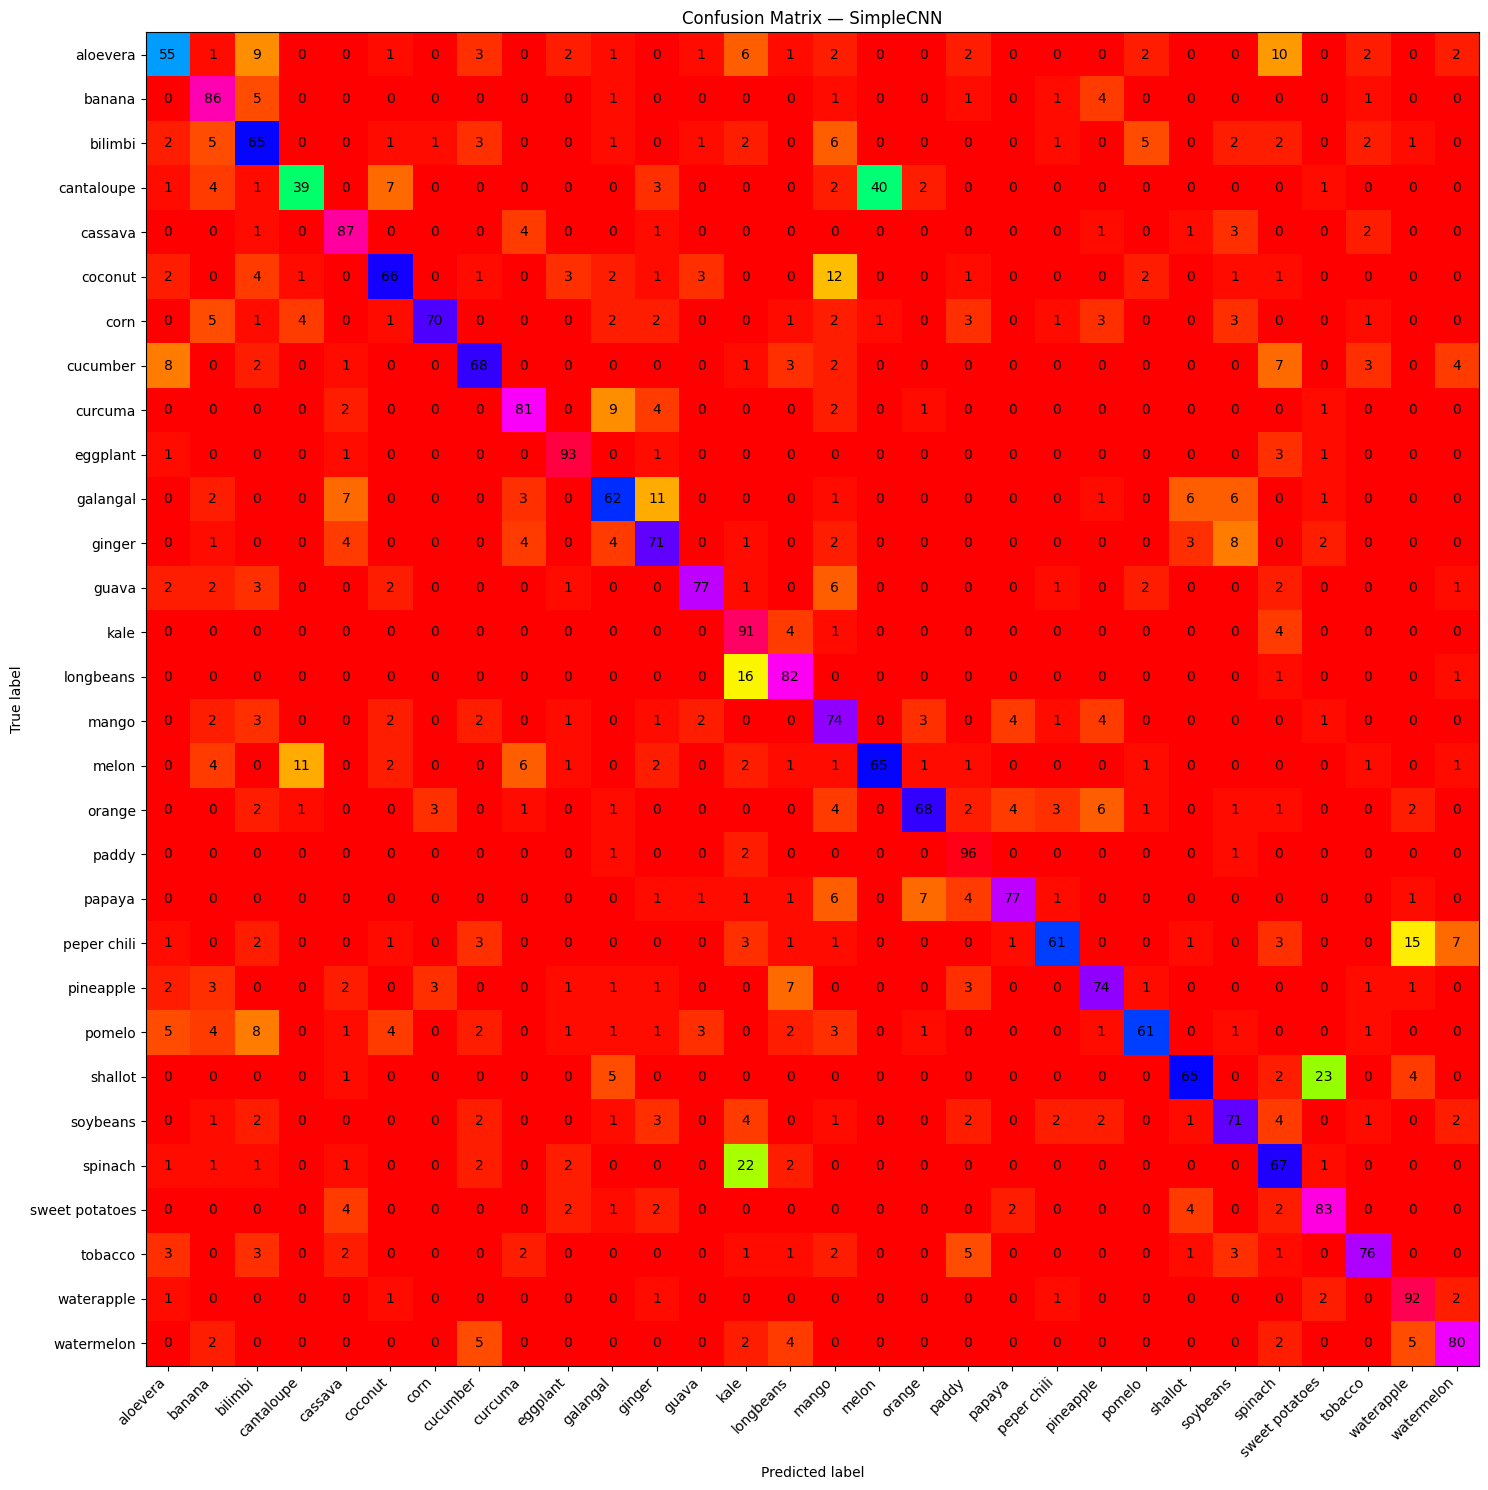

                precision    recall  f1-score   support

      aloevera       0.65      0.55      0.60       100
        banana       0.70      0.86      0.77       100
       bilimbi       0.58      0.65      0.61       100
    cantaloupe       0.70      0.39      0.50       100
       cassava       0.77      0.87      0.82       100
       coconut       0.75      0.66      0.70       100
          corn       0.91      0.70      0.79       100
      cucumber       0.75      0.69      0.72        99
       curcuma       0.80      0.81      0.81       100
      eggplant       0.87      0.93      0.90       100
      galangal       0.67      0.62      0.64       100
        ginger       0.67      0.71      0.69       100
         guava       0.88      0.77      0.82       100
          kale       0.59      0.91      0.71       100
     longbeans       0.75      0.82      0.78       100
         mango       0.56      0.74      0.64       100
         melon       0.61      0.65      0.63  

In [ ]:
if best_simplecnn_path:
    baseline = SimpleLightningModule.load_from_checkpoint(best_simplecnn_path, model=SimpleCNN(num_classes).to(device),
                                             num_classes=num_classes, lr=1e-3, weight_decay=1e-4)

test_metrics_baseline = trainer_baseline.test(baseline, dataloaders=test_loader)

cm_metric = MulticlassConfusionMatrix(num_classes=num_classes)
baseline.eval().to(device)
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = baseline(xb.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_true.append(yb)
        cm_metric.update(preds, yb)
cm = cm_metric.compute().numpy()

plt.figure(figsize=(15,15))
plt.imshow(cm, interpolation='nearest', cmap='hsv')
plt.title("Confusion Matrix — SimpleCNN")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout(); plt.show()

y_true = torch.cat(all_true).numpy()
y_pred = torch.cat(all_preds).numpy()
print(classification_report(y_true, y_pred, target_names=class_names))

#Putting the metrics into a dataset for comparing with VGG

Final SimpleCNN metrics: {'test_loss': 0.8098556399345398, 'test_acc': 0.7348013520240784, 'test_precision': 0.7442073822021484, 'test_recall': 0.7348013520240784, 'test_f1': 0.7326453924179077}
Saved metrics to simplecnn_final_metrics.csv


,Metric,Value
0,Accuracy,0.734801
1,Precision,0.744207
2,Recall,0.734801
3,F1-Score,0.732645


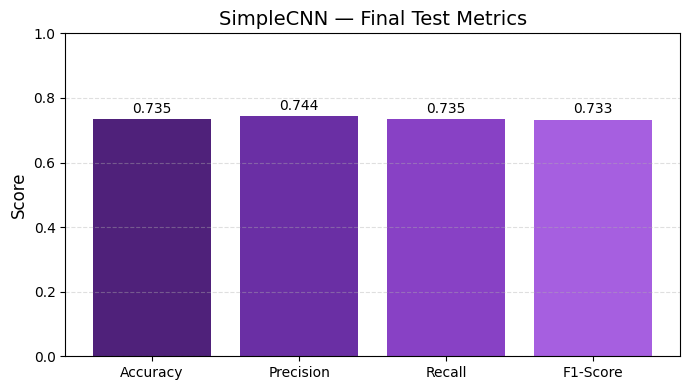

In [ ]:
import pandas as pd

def extract_last_metrics(trainer):
    out = {}
    for k, v in trainer.callback_metrics.items():
        try:
            out[k] = float(v.cpu().item())
        except Exception:
            pass
    return out

simplecnn_metrics = extract_last_metrics(trainer_baseline)
print("Final SimpleCNN metrics:", simplecnn_metrics)

keys   = ["test_acc", "test_precision", "test_recall", "test_f1"]
labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
vals   = [simplecnn_metrics.get(k, np.nan) for k in keys]

df_simplecnn = pd.DataFrame({
    "Metric": labels,
    "Value": vals
})
df_simplecnn.to_csv("simplecnn_final_metrics.csv", index=False)
print("Saved metrics to simplecnn_final_metrics.csv")
display(df_simplecnn)

plt.figure(figsize=(7,4))
bars = plt.bar(labels, vals, color=["#3C096C", "#5A189A", "#7B2CBF", "#9D4EDD"], alpha=0.9)
plt.title("SimpleCNN — Final Test Metrics", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


#VGG

In [ ]:
num_classes = 30

def build_vgg16(
    num_classes: int,
    pretrained: bool = True,
    freeze_features: bool = True,
):
    weights = models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None
    vgg = models.vgg16(weights=weights)

    if freeze_features:
        for p in vgg.features.parameters():
            p.requires_grad = False

    in_features = vgg.classifier[6].in_features
    vgg.classifier[6] = nn.Linear(in_features, num_classes)

    return vgg


In [ ]:



vgg_model = build_vgg16(num_classes=num_classes,
                        pretrained=True,
                        freeze_features=True).to(device)


class SimpleLightningModule(pl.LightningModule):
    def __init__(self, model: nn.Module, num_classes: int, lr=1e-3, weight_decay=1e-4):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay

        # Metrics
        self.acc  = MulticlassAccuracy(num_classes=num_classes)
        self.prec = MulticlassPrecision(num_classes=num_classes, average="macro")
        self.rec  = MulticlassRecall(num_classes=num_classes, average="macro")
        self.f1   = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch, stage: str):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)
        self.acc.update(preds, y)
        self.prec.update(preds, y)
        self.rec.update(preds, y)
        self.f1.update(preds, y)
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, batch_size=x.size(0))
        return loss

    def training_step(self, batch, idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, idx):
        return self._shared_step(batch, "val")

    def test_step(self, batch, idx):
        return self._shared_step(batch, "test")

    def _epoch_metrics(self, stage: str):
        self.log(f"{stage}_acc",  self.acc.compute(),  prog_bar=True)
        self.log(f"{stage}_precision", self.prec.compute(), prog_bar=False)
        self.log(f"{stage}_recall",    self.rec.compute(),  prog_bar=False)
        self.log(f"{stage}_f1",        self.f1.compute(),   prog_bar=True)
        self.acc.reset(); self.prec.reset(); self.rec.reset(); self.f1.reset()

    def on_train_epoch_end(self): self._epoch_metrics("train")
    def on_validation_epoch_end(self): self._epoch_metrics("val")
    def on_test_epoch_end(self): self._epoch_metrics("test")

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", patience=2, factor=0.5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 164MB/s]


In [ ]:
vgg_lit_pl = SimpleLightningModule(
    build_vgg16(num_classes=num_classes, pretrained=True, freeze_features=True).to(device),
    num_classes=num_classes, lr=1e-3, weight_decay=1e-4
)

ckpt_vgg = ModelCheckpoint(
    monitor="val_acc", mode="max", save_top_k=1, filename="vgg16-best"
)
es_vgg   = EarlyStopping(monitor="val_loss", mode="min", patience=5)
lr_vgg   = LearningRateMonitor(logging_interval='epoch')

trainer_vgg = pl.Trainer(
    max_epochs=15,
    accelerator="auto", devices=1,
    callbacks=[ckpt_vgg, es_vgg, lr_vgg],
    log_every_n_steps=10,
    deterministic=True
)

trainer_vgg.fit(vgg_lit_pl, train_dataloaders=train_loader, val_dataloaders=val_loader)
best_vgg_path = ckpt_vgg.best_model_path
best_vgg_path

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ VGG                 │  134 M │ train │     0 │
│ 1 │ acc   │ MulticlassAccuracy  │      0 │ train │     0 │
│ 2 │ prec  │ MulticlassPrecision │      0 │ train │     0 │
│ 3 │ rec   │ MulticlassRecall    │      0 │ train │     0 │
│ 4 │ f1    │ MulticlassF1Score   │      0 │ train │     0 │
└───┴───────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 119 M                                                                                            
Non-trainable params: 14.7 M                                                                                       
Total params: 134 M                                                                                                
Total estimated model params size (MB): 537                                                                        
Modules in train mode: 46                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassPrecision was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassRecall was called before the ``update`` method which may lead to errors, as metric states have not
yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassF1Score was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


'/content/lightning_logs/version_1/checkpoints/vgg16-best.ckpt'

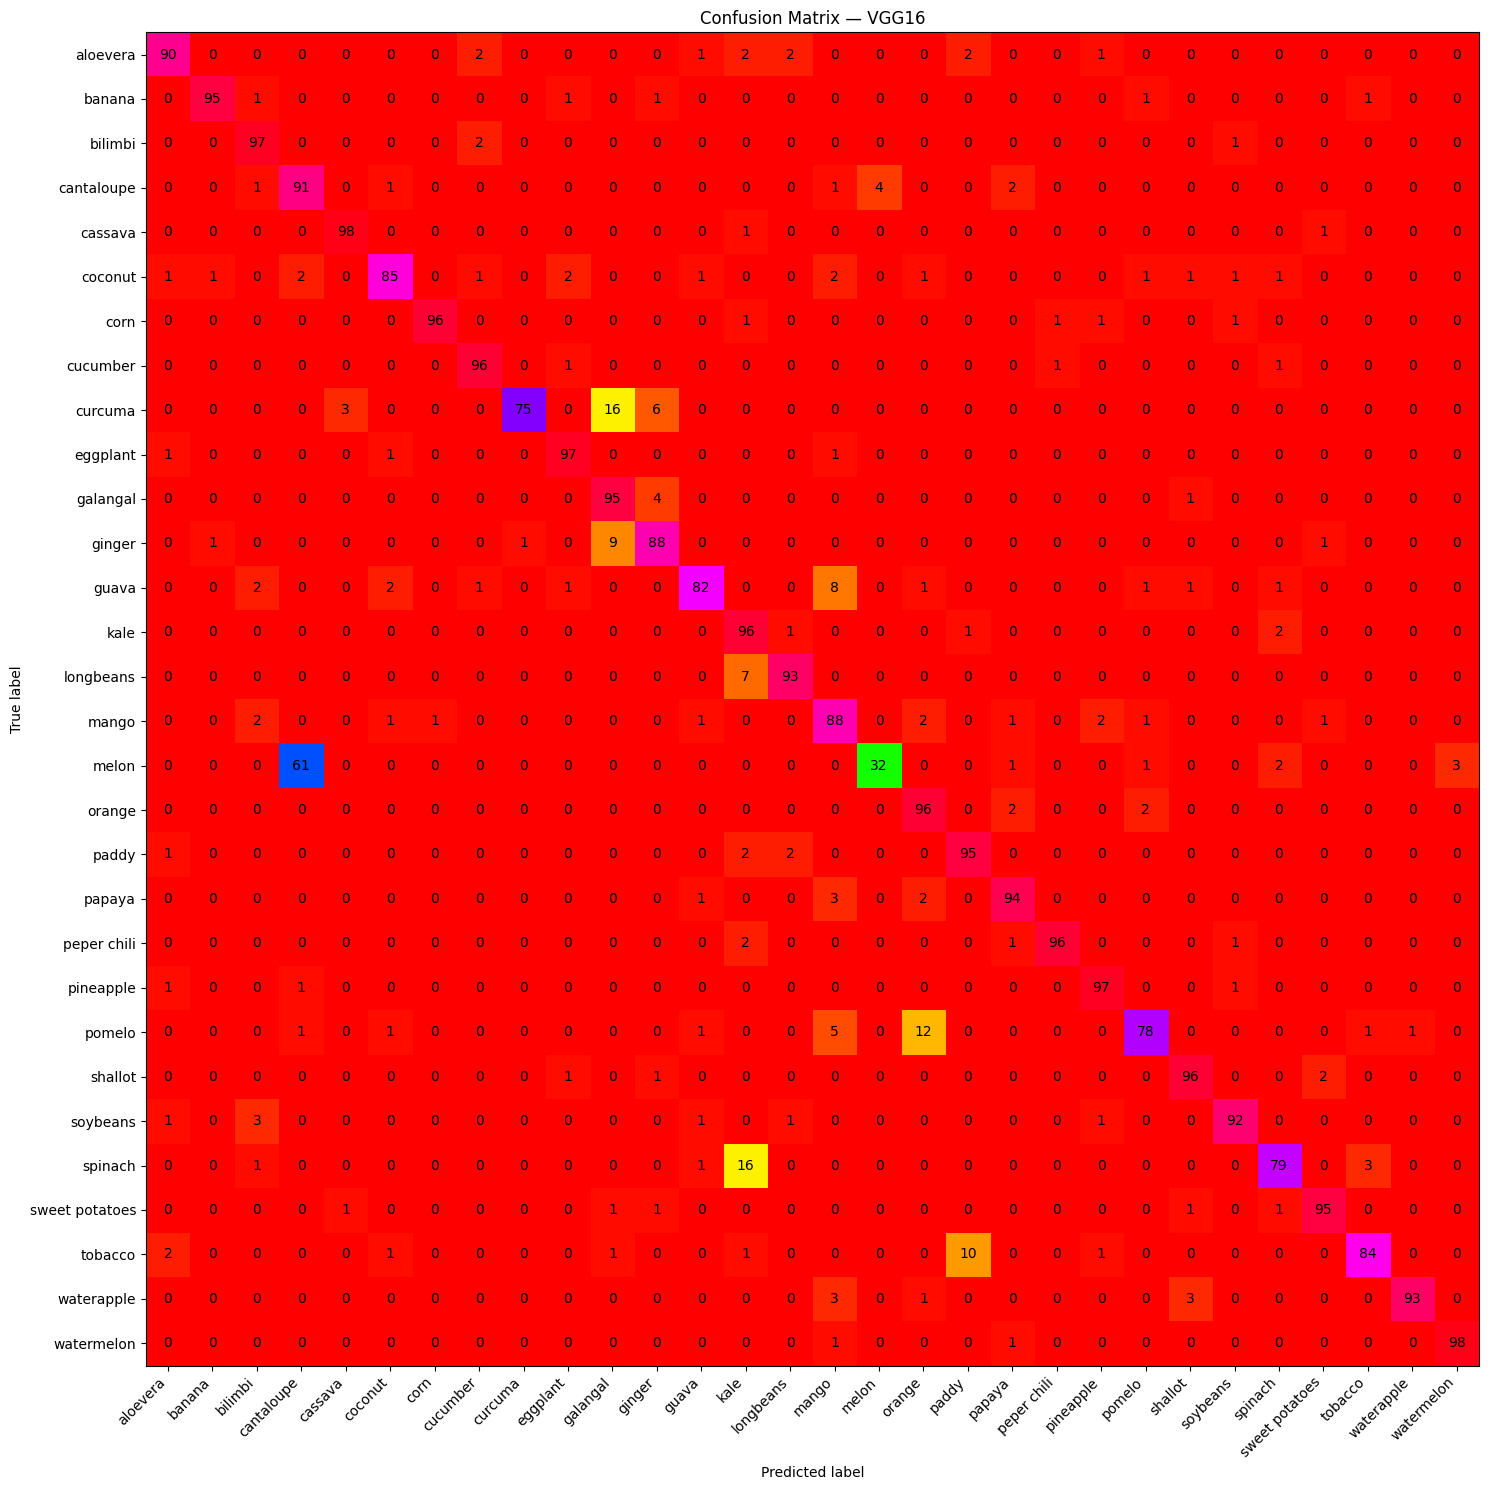

VGG16  Classification report:
                 precision    recall  f1-score   support

      aloevera       0.93      0.90      0.91       100
        banana       0.98      0.95      0.96       100
       bilimbi       0.91      0.97      0.94       100
    cantaloupe       0.58      0.91      0.71       100
       cassava       0.96      0.98      0.97       100
       coconut       0.92      0.85      0.89       100
          corn       0.99      0.96      0.97       100
      cucumber       0.94      0.97      0.96        99
       curcuma       0.99      0.75      0.85       100
      eggplant       0.94      0.97      0.96       100
      galangal       0.78      0.95      0.86       100
        ginger       0.87      0.88      0.88       100
         guava       0.92      0.82      0.87       100
          kale       0.75      0.96      0.84       100
     longbeans       0.94      0.93      0.93       100
         mango       0.79      0.88      0.83       100
         melon  

,Metric,Value
0,Accuracy,0.896264
1,Precision,0.906452
2,Recall,0.896300
3,F1-Score,0.893488


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
vgg_lit_pl.eval().to(device)

cm_metric_vgg = MulticlassConfusionMatrix(num_classes=num_classes)
all_preds_vgg, all_true_vgg = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = vgg_lit_pl(xb.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds_vgg.append(preds)
        all_true_vgg.append(yb)
        cm_metric_vgg.update(preds, yb)

cm_vgg = cm_metric_vgg.compute().numpy()

plt.figure(figsize=(15, 15))
plt.imshow(cm_vgg, interpolation='nearest', cmap='hsv')
plt.title("Confusion Matrix — VGG16")
if 'class_names' in globals() and len(class_names) == num_classes:
    plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
    plt.yticks(range(num_classes), class_names)
else:
    plt.xticks(range(num_classes)); plt.yticks(range(num_classes))
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, int(cm_vgg[i, j]), ha="center", va="center")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout(); plt.show()

y_true_vgg = torch.cat(all_true_vgg).numpy()
y_pred_vgg = torch.cat(all_preds_vgg).numpy()

print("VGG16  Classification report:\n",
      classification_report(y_true_vgg, y_pred_vgg,
                            target_names=class_names if 'class_names' in globals() and len(class_names)==num_classes else None))


acc_vgg  = accuracy_score(y_true_vgg, y_pred_vgg)
prec_vgg, rec_vgg, f1_vgg, _ = precision_recall_fscore_support(y_true_vgg, y_pred_vgg, average="macro")

vgg_metrics = {
    "test_acc": acc_vgg,
    "test_precision": prec_vgg,
    "test_recall": rec_vgg,
    "test_f1": f1_vgg
}

df_vgg = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value":  [vgg_metrics["test_acc"], vgg_metrics["test_precision"], vgg_metrics["test_recall"], vgg_metrics["test_f1"]]
})
df_vgg.to_csv("vgg16_final_metrics.csv", index=False)
print("Saved metrics to vgg16_final_metrics.csv")
display(df_vgg)

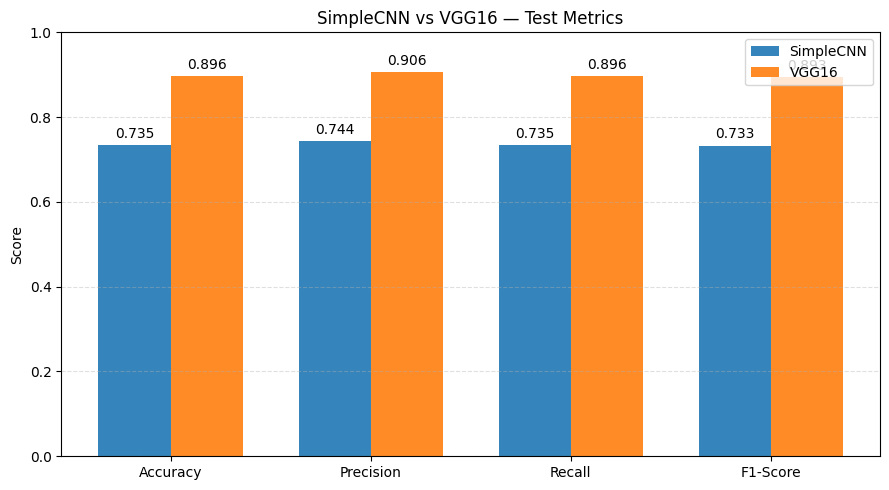

In [ ]:
keys   = ["test_acc", "test_precision", "test_recall", "test_f1"]
labels = ["Accuracy", "Precision", "Recall", "F1-Score"]

vals_simplecnn = [simplecnn_metrics.get(k, np.nan) for k in keys]
vals_vgg       = [vgg_metrics.get(k, np.nan)       for k in keys]

x = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(9, 5))
b1 = plt.bar(x - width/2, vals_simplecnn, width, label="SimpleCNN", alpha=0.9)
b2 = plt.bar(x + width/2, vals_vgg,       width, label="VGG16",     alpha=0.9)

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("SimpleCNN vs VGG16 — Test Metrics")
plt.ylim(0, 1)
plt.legend()

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}",
                 ha="center", va="bottom", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

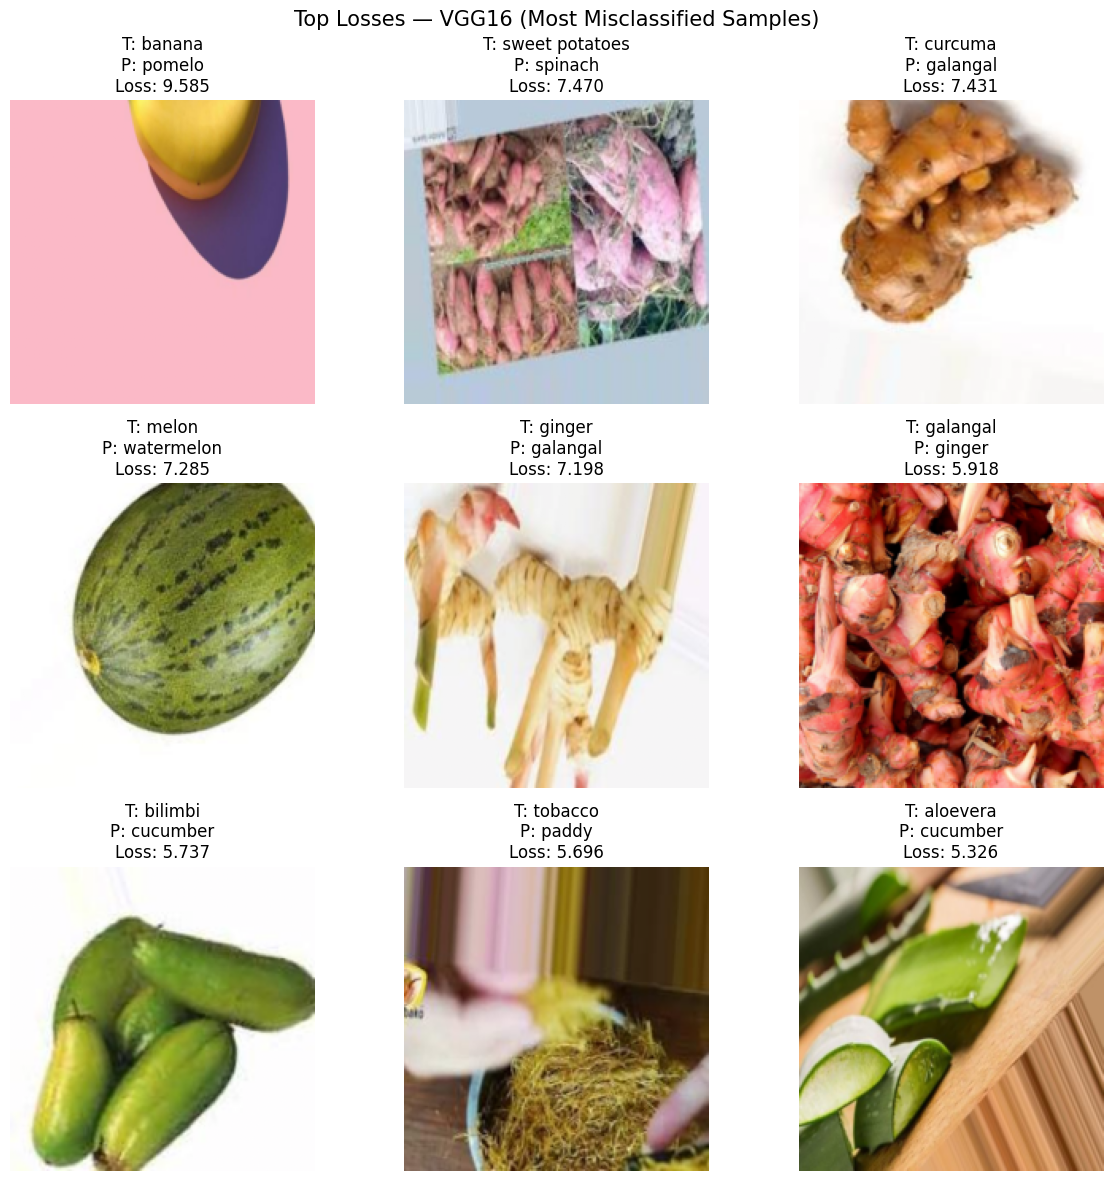

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

vgg_lit_pl.eval().to(device)

images, preds, labels, losses = [], [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = vgg_lit_pl(xb)
        batch_loss = F.cross_entropy(logits, yb, reduction="none")
        losses.extend(batch_loss.detach().cpu().tolist())
        preds.extend(logits.argmax(dim=1).cpu().tolist())
        labels.extend(yb.cpu().tolist())
        images.extend(xb.cpu())

losses = np.array(losses)
sorted_idx = np.argsort(-losses)

N = 9
top_idx = sorted_idx[:N]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(top_idx):
    img = images[idx]
    true_label = labels[idx]
    pred_label = preds[idx]
    loss_val = losses[idx]

    img_show = img.clone()
    if img_show.shape[0] == 3:  # RGB
        img_show = img_show * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_show = img_show + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        img_show = torch.clamp(img_show, 0, 1)

    plt.subplot(3, 3, i+1)
    plt.imshow(np.transpose(img_show.numpy(), (1, 2, 0)))
    if 'class_names' in globals() and len(class_names) == num_classes:
        plt.title(f"T: {class_names[true_label]}\nP: {class_names[pred_label]}\nLoss: {loss_val:.3f}")
    else:
        plt.title(f"T: {true_label} | P: {pred_label}\nLoss: {loss_val:.3f}")
    plt.axis("off")

plt.suptitle("Top Losses — VGG16 (Most Misclassified Samples)", fontsize=15)
plt.tight_layout()
plt.show()
